<a href="https://colab.research.google.com/github/sreeraj2255rajesh-lab/Financial-Data-Analysis/blob/main/Python_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANALYSIS OF BITCOIN : PRICE TRENDS, YEARLY RETURNS, VOLATILITY (2014-2026)

BUSINESS OBJECTIVE:
To implement a Python-based empirical analysis of Bitcoin's historical dataset (2014–2026), evaluating long-term price action, annual return profiles, and volatility compression to model the asset's structural market maturation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv("/content/drive/MyDrive/bitcoin_dataset.csv")

In [9]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [10]:
df.shape # 4280 rows and 7 columns

(4280, 7)

In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4280 entries, 0 to 4279
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4280 non-null   object 
 1   Open       4280 non-null   float64
 2   High       4280 non-null   float64
 3   Low        4280 non-null   float64
 4   Close      4280 non-null   float64
 5   Adj Close  4280 non-null   float64
 6   Volume     4280 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 234.2+ KB


In [ ]:
print("Missing values:")
df.isnull().sum()

Missing values:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...,...
4275,2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,71319.773438,43378836121
4276,2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,66703.656250,54990073882
4277,2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213
4278,2026-06-04,64020.070312,64664.445312,61335.750000,63801.574219,63801.574219,63800151780


In [11]:
df["Date"]=pd.to_datetime(df["Date"])
print(df["Date"])

0      2014-09-17
1      2014-09-18
2      2014-09-19
3      2014-09-20
4      2014-09-21
          ...    
4275   2026-06-01
4276   2026-06-02
4277   2026-06-03
4278   2026-06-04
4279   2026-06-05
Name: Date, Length: 4280, dtype: datetime64[ns]


In [ ]:
df.index


RangeIndex(start=0, stop=4280, step=1)

In [12]:
df.sort_values("Date")

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...,...
4275,2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,71319.773438,43378836121
4276,2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,66703.656250,54990073882
4277,2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213
4278,2026-06-04,64020.070312,64664.445312,61335.750000,63801.574219,63801.574219,63800151780


In [13]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [14]:
# Desciptive statistics
df.describe().round(2)


,Date,Open,High,Low,Close,Adj Close,Volume
count,4280,4280.00,4280.00,4280.00,4280.00,4280.00,4.280000e+03
mean,2020-07-26 12:00:00,28623.33,29188.32,28019.75,28636.45,28636.45,2.230348e+10
min,2014-09-17 00:00:00,176.90,211.73,171.51,178.10,178.10,5.914570e+06
25%,2017-08-21 18:00:00,3452.19,3504.09,3391.94,3458.81,3458.81,1.676575e+09
50%,2020-07-26 12:00:00,11536.73,11850.33,11288.41,11564.33,11564.33,1.802679e+10
75%,2023-07-01 06:00:00,46401.47,47432.59,45184.17,46446.92,46446.92,3.446429e+10
max,2026-06-05 00:00:00,124752.14,126198.07,123196.05,124752.53,124752.53,3.509679e+11
std,NaN,32442.20,32986.01,31852.79,32442.45,32442.45,2.294359e+10


INTEPRETATION: Descriptive statistics shows that average closing price($28,636.45) is significantly higher than the median price($11,564.33) because bitcoin touched massive higher of $124,752.53 which pull the average up. A high standard deviation of $32,442.45 reflects the extreme price expansion and wide swings Bitcoin experienced over this 12-year period.

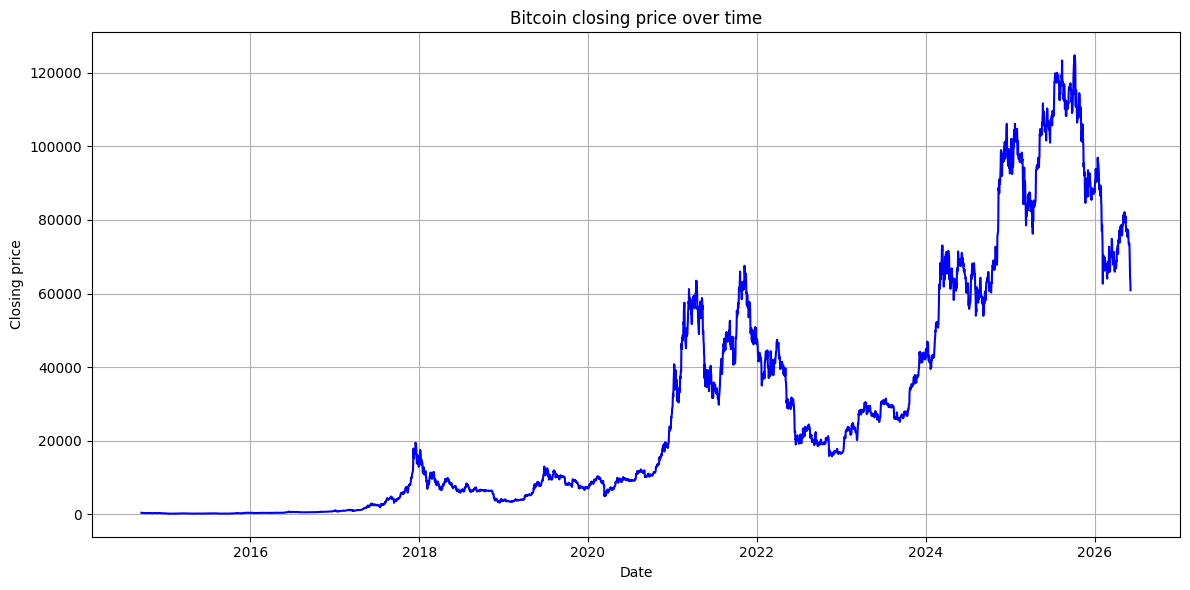

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Close"],
"b",
label = "Closing price")
plt.title("Bitcoin closing price over time")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.tight_layout()
plt.grid(True)
plt.show()

INTERPRETATIION : This chart indicates that Bitcoin's price overall increased significantly from 2014 to 2026. In the long run, the price made higher highs and higher lows up until late 2025, where it reached a peak of over $124,752.53. However, after late 2025, the price entered a sharp decline, breaking its market structure (change of character) in early 2026 by forming lower highs and lower lows. This confirms that Bitcoin is currently in a macro downtrend phase.




In [20]:
df["Year"] = df["Date"].dt.year
Yearly_data= df.groupby("Year")["Close"].last().to_frame()
Yearly_data["Year_end_return"] = Yearly_data.pct_change()*100
Yearly_data.head()
Yearly_data.index

Index([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026],
      dtype='int32', name='Year')

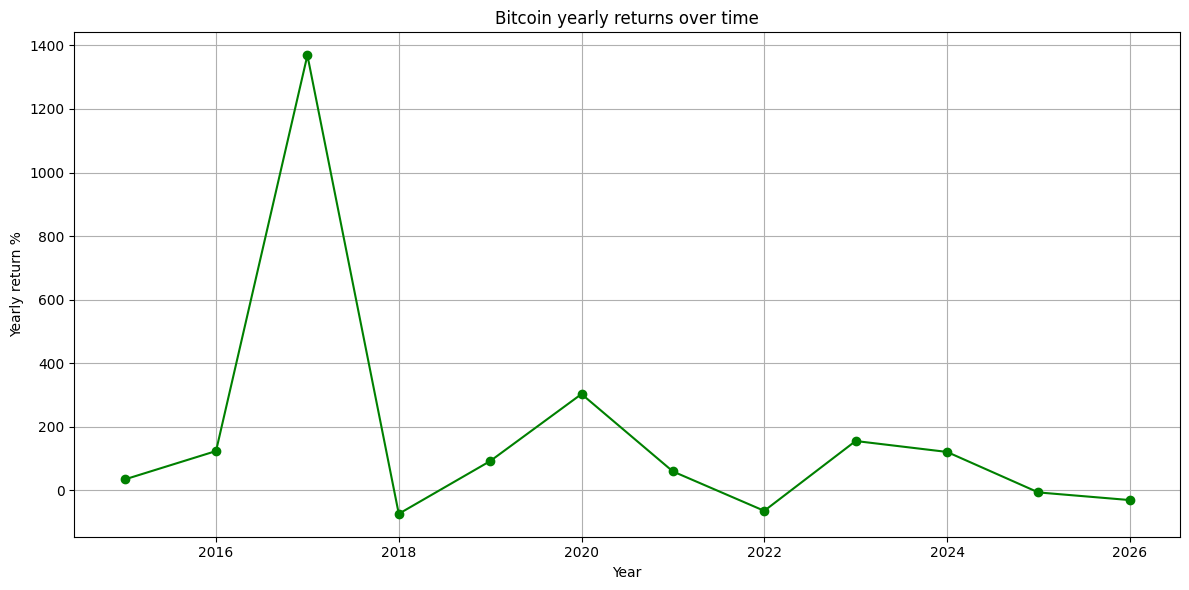

In [17]:
# To check yearly wise return
plt.figure(figsize=(12,6))

plt.plot(Yearly_data.index,Yearly_data["Year_end_return"],
"go-",
label = "Bitcoin Yearly Returns Over Time")
plt.title("Bitcoin yearly returns over time")
plt.xlabel("Year")
plt.ylabel("Yearly return %")
plt.grid(True)
plt.tight_layout()
plt.show()

INTERPRETATION: This chart shows that while Bitcoin’s overall price increased from 2014 to 2026, annual percentage returns reached an massive peak in 2017 (around 1370%). After 2017, yearly returns fell sharply into negative territory in 2018 before rebounding to a lower peak in 2020 (~300%). Subsequent cycles, such as in 2023–2024, brought even lower percentage gains before dropping back into negative returns in 2025–2026. Overall, the graph highlights a clear trend of diminishing percentage returns as the market matures over time.

In [25]:
df["Daily returns"] = df["Close"].pct_change()
annual_volatility = df.groupby("Year")["Daily returns"].std()




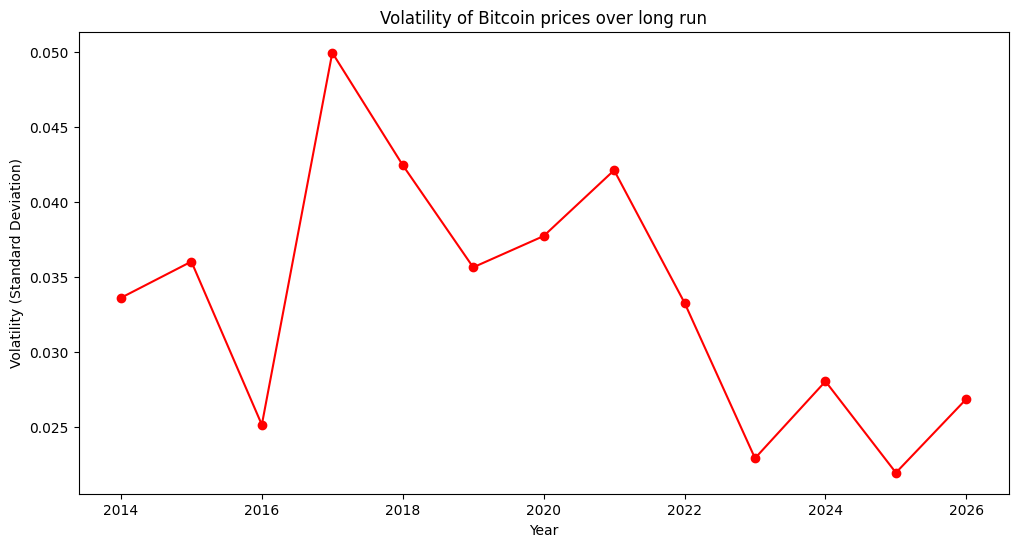

In [23]:
plt.figure(figsize=(12,6))
plt.plot(annual_volatility.index,annual_volatility,
"ro-",
label = "Annual Volatility of Bitcoin Returns")
plt.title("Volatility of Bitcoin prices over long run")
plt.xlabel("Year")
plt.ylabel("Volatility (Standard Deviation)")
plt.tight_layout
plt.show()

INTREPRETATION : This chart shows that while Bitcoin’s price volatility experiences cyclical fluctuations, its long-term trajectory is trending downward from 2014 to 2026. Volatility reached an all-time peak in 2017 at 0.050 (5.0%) standard deviation, followed by a lower secondary peak in 2021 at approximately 0.042. Over the subsequent years (2022–2026), volatility compressed significantly, reaching historical lows around 0.022–0.023. Overall, the chart demonstrates that as Bitcoin’s market has matured and deepened over time, its price fluctuations have become progressively less severe.

LIMITATION:
1. The chart purely on closing prices over the year.The future price movements are also dependends on macro economic factors such as interest rates, equity market movement etc.

2. Measuring volatility purely through standard deviation treats upside price spikes and downside crashes equally. This hides the actual negative volatility which is unfavourable to an investors.

SUGGESTIONS:
1. The long-term chart demonstrates that Bitcoin acts as an expanding macro asset, but its return profile has fundamentally evolved. Volatility has compressed from 5% down to 2.2% showing that the asset is institutionalizing and becoming more stable over time.

2. While yearly returns are diminishing compared to 2017, Bitcoin still outperforms other traditional asset classes during all periods.  The 2026 price breakdown confirms we are currently in a corrective phase, which could be considered for accumalating by proper risk management.

3. Rather than placing a lump-sum bet, we recommend a small bet on Bitcoin by considering macro economic situation